In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['figure.dpi'] = 100

In [3]:
df = pd.read_csv('superstore.csv', encoding='latin1')

print(f"Shape: {df.shape}")
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
# nulls and duplicate
print("Null Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Null Values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicates: 0


In [6]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


In [7]:
# data cleaning
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df.columns = df.columns.str.replace(' ', '_')

In [8]:
#NEW COLUMNS 
df['Shipping_Days'] = (df['Ship_Date'] - df['Order_Date']).dt.days
df['Profit_Margin'] = (df['Profit'] / df['Sales']).round(4)
df['Discount_%'] = df['Discount'] * 100
df['Order_Year'] = df['Order_Date'].dt.year
df['Order_Month'] = df['Order_Date'].dt.to_period('M')

In [9]:
total_sales = df['Sales'].sum()
total_sales

2297200.8603000003

In [10]:
total_profit = df['Profit'].sum()
total_profit

286397.0217

In [11]:
total_orders = df.shape[0]
total_orders

9994

In [12]:
avg_discount = df['Discount'].mean()
avg_discount

0.15620272163298934

In [13]:
loss_orders = df[df['Profit'] < 0].shape[0]
loss_orders

1871

In [14]:
loss_pct = (loss_orders/ total_orders)*100
loss_pct

18.721232739643785

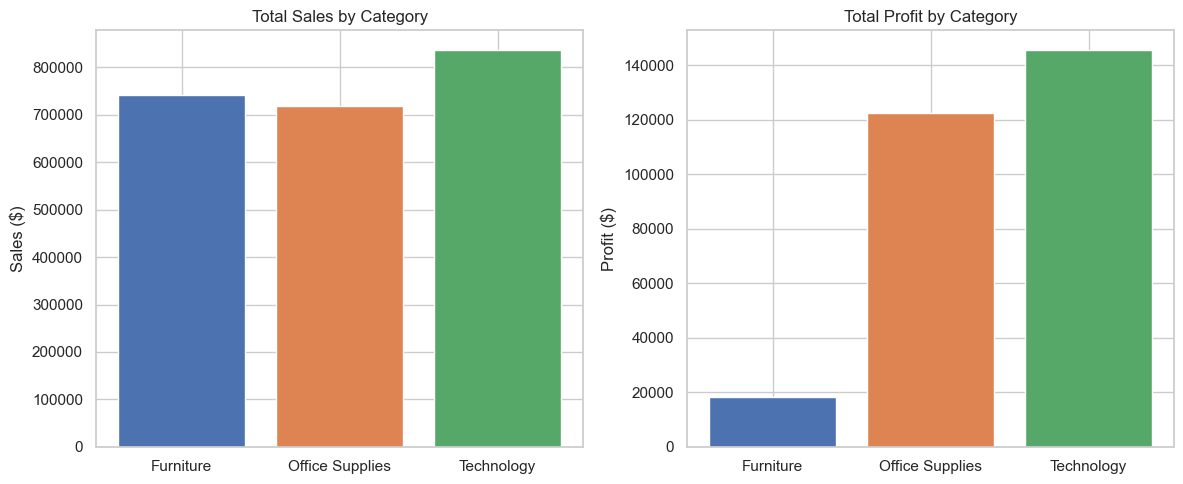

In [15]:
# sales & profit by category
cat_df = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(cat_df['Category'], cat_df['Sales'],
            color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('Total Sales by Category')
axes[0].set_ylabel('Sales ($)')

axes[1].bar(cat_df['Category'], cat_df['Profit'],
            color=['#4C72B0', '#DD8452', '#55A868'])
axes[1].set_title('Total Profit by Category')
axes[1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.show()

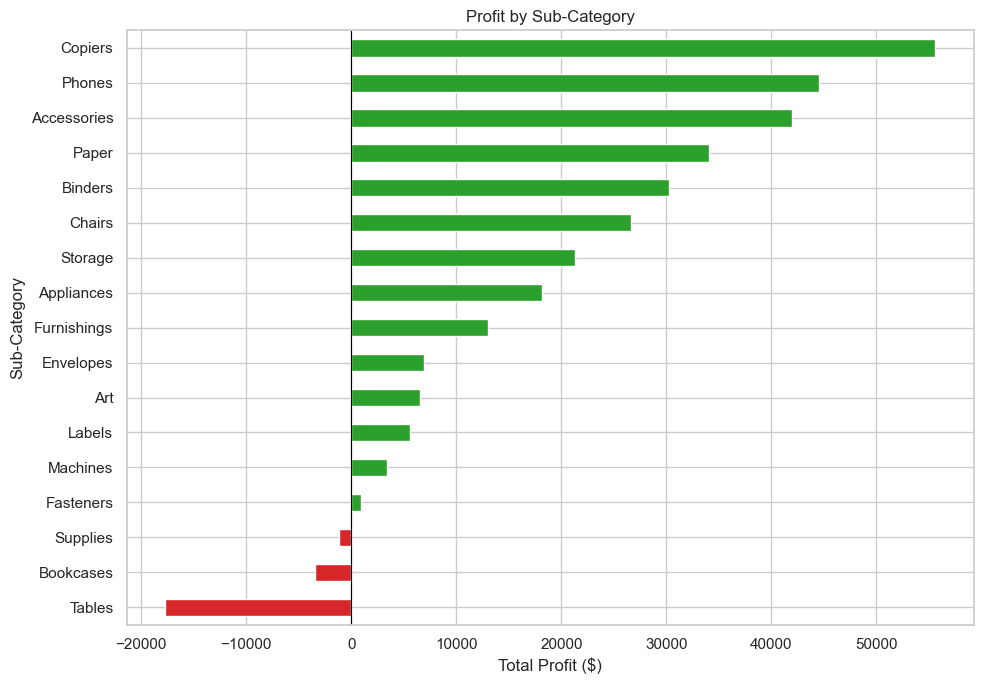

In [16]:
# Sub-Category Profit
subcat_df = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors_list = ['#d62728' if x < 0 else '#2ca02c' for x in subcat_df]

plt.figure(figsize=(10, 7))
subcat_df.plot(kind='barh', color=colors_list)
plt.title('Profit by Sub-Category')
plt.xlabel('Total Profit ($)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

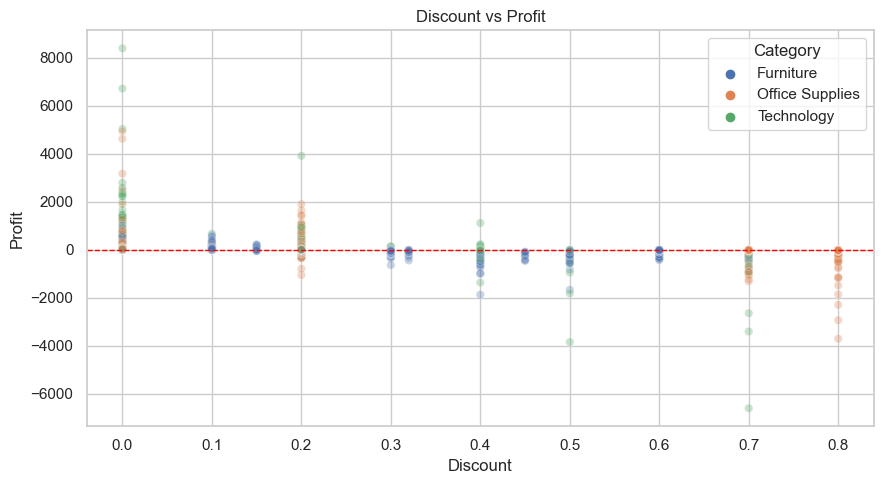

In [17]:
# Discount vs Profit
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.3, hue='Category')
plt.title('Discount vs Profit')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

In [18]:
disc_profit = df.groupby('Discount')['Profit'].mean().reset_index()
disc_profit

,Discount,Profit
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.679636
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212


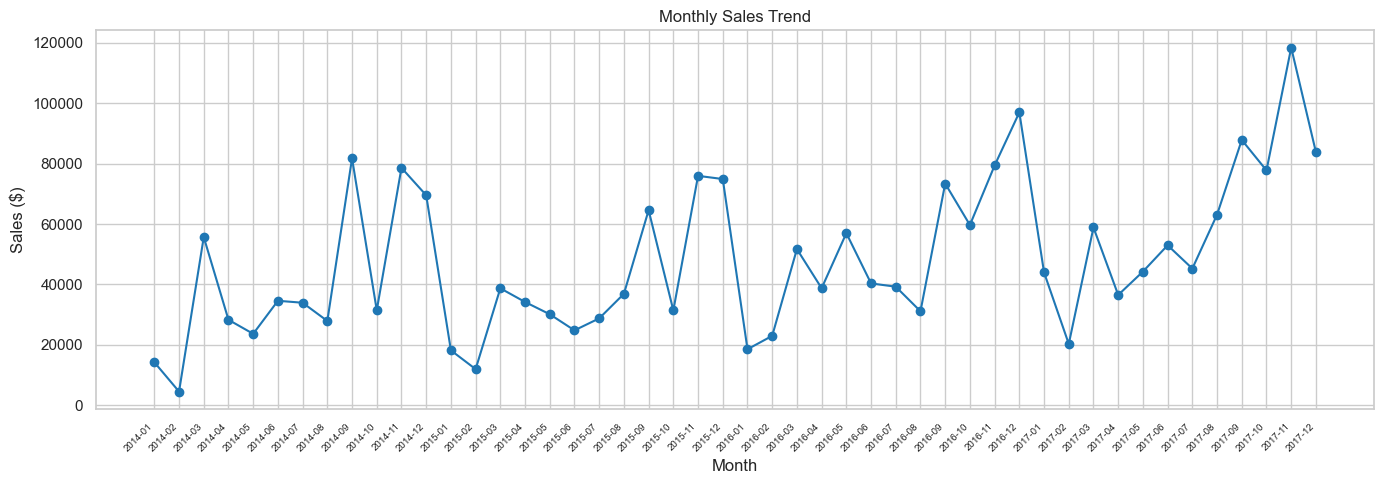

In [19]:
# Monthly Sales Trend
monthly = df.groupby('Order_Month')['Sales'].sum().reset_index()
monthly['Order_Month'] = monthly['Order_Month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly['Order_Month'], monthly['Sales'],
         marker='o', linewidth=1.5, color='#1f77b4')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

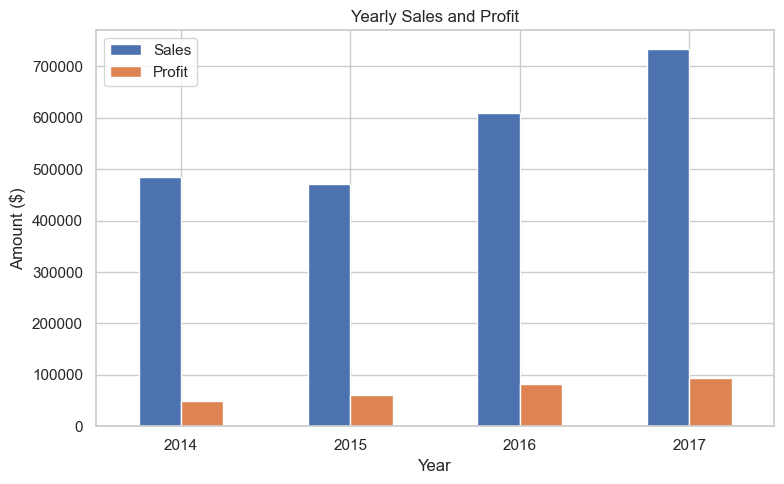

In [20]:
# Yearly Sales & Profit
yearly = df.groupby('Order_Year')[['Sales', 'Profit']].sum()

yearly.plot(kind='bar', figsize=(8, 5))
plt.title('Yearly Sales and Profit')
plt.xlabel('Year')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

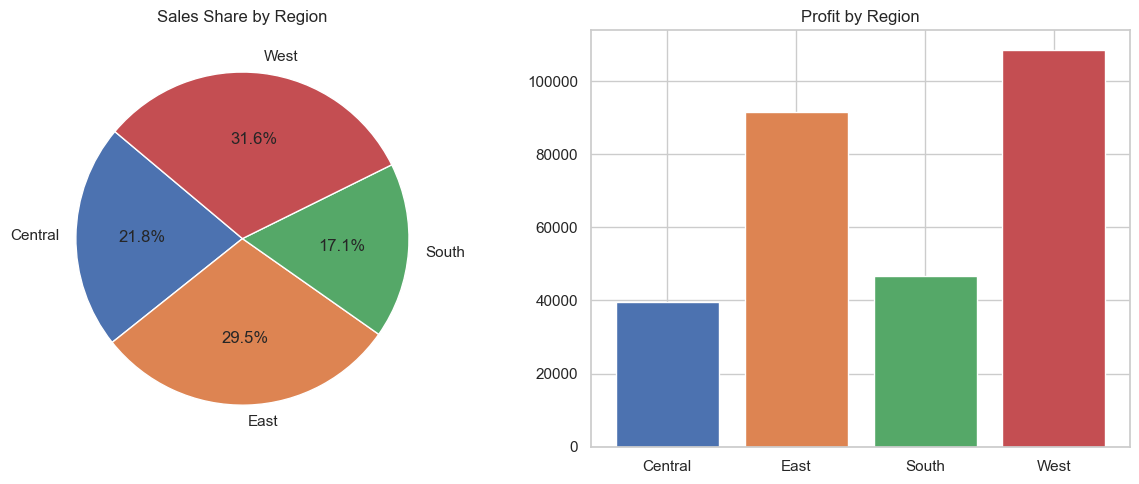

In [21]:
# Sales by Region
region_df = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(region_df['Sales'], labels=region_df['Region'],
            autopct='%1.1f%%', startangle=140)
axes[0].set_title('Sales Share by Region')
axes[1].bar(region_df['Region'], region_df['Profit'],
            color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[1].set_title('Profit by Region')
plt.tight_layout()
plt.show()

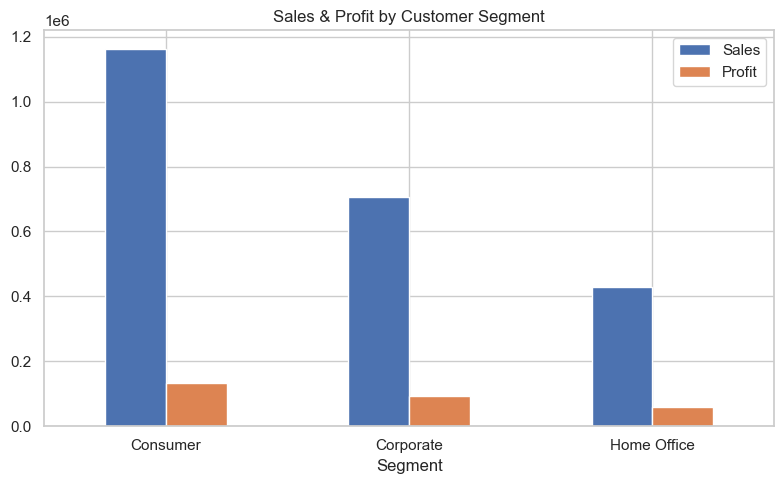

In [22]:
# Sales by Segment
seg_df = df.groupby('Segment')[['Sales', 'Profit']].sum().reset_index()

seg_df.set_index('Segment').plot(kind='bar', figsize=(8, 5))
plt.title('Sales & Profit by Customer Segment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

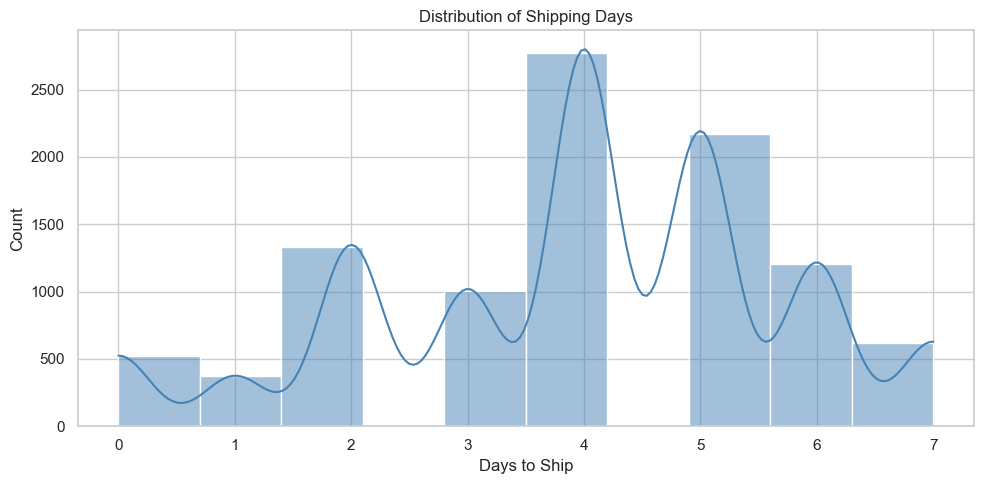

Average Shipping Days: 4.0


In [23]:
# Shipping Days Distribution
sns.histplot(df['Shipping_Days'], bins=10, kde=True, color='steelblue')
plt.title('Distribution of Shipping Days')
plt.xlabel('Days to Ship')
plt.tight_layout()
plt.show()

print(f"Average Shipping Days: {df['Shipping_Days'].mean():.1f}")

In [24]:
# Top 10 Loss-Making Products
top_loss = df.groupby('Product_Name')[['Sales','Profit']].sum()\
             .sort_values('Profit').head(10)
print("Top 10 Loss-Making Products:")
print(top_loss.to_string())

Top 10 Loss-Making Products:
                                                                       Sales     Profit
Product_Name                                                                           
Cubify CubeX 3D Printer Double Head Print                          11099.963 -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                          16829.901 -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           7999.980 -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            9917.640 -2876.1156
Bush Advantage Collection Racetrack Conference Table                9544.725 -1934.3976
GBC DocuBind P400 Electric Binding System                          17965.068 -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit              22638.480 -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                 16656.200 -1299.1836
Balt Solid Wood Round Tables                                        6518.754 -1201.0581
Box

In [25]:
#Top 10 Most Profitable Products
top_profit = df.groupby('Product_Name')[['Sales','Profit']].sum()\
              .sort_values('Profit', ascending=False).head(10)
print("Top 10 Most Profitable Products:")
print(top_profit.to_string())

Top 10 Most Profitable Products:
                                                                                 Sales      Profit
Product_Name                                                                                      
Canon imageCLASS 2200 Advanced Copier                                        61599.824  25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind  27453.384   7753.0390
Hewlett Packard LaserJet 3310 Copier                                         18839.686   6983.8836
Canon PC1060 Personal Laser Copier                                           11619.834   4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                    18374.895   4094.9766
Ativa V4110MDD Micro-Cut Shredder                                             7699.890   3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                             14299.890   3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                  

In [26]:
df.to_csv('superstore_clean.csv', index=False)

In [27]:
print("""

     SUPERSTORE ANALYSIS - KEY FINDINGS

1. Technology is the most profitable category.
2. Furniture (Tables) consistently loses money.
3. Discounts above 20% cause average losses.
4. 18.7% of all orders are loss-making.
5. West region leads in sales and profit.
6. Sales goes up in October-Dcember.
7. Binders & Machines get highest discounts.
8. Copiers and Phones are the most Profitable products.

""")



     SUPERSTORE ANALYSIS - KEY FINDINGS

1. Technology is the most profitable category.
2. Furniture (Tables) consistently loses money.
3. Discounts above 20% cause average losses.
4. 18.7% of all orders are loss-making.
5. West region leads in sales and profit.
6. Sales goes up in October-Dcember.
7. Binders & Machines get highest discounts.
8. Copiers and Phones are the most Profitable products.


